# Dr. Case Notebook
# Exploratory Data Analysis (EDA)

- Author: [Denise Case](https://github.com/denisecase/)
- Repository: [datafun-04-eda](https://github.com/denisecase/datafun-04-eda/)
- Purpose: Demonstrate a reliable, repeatable EDA process for a new tabular dataset
- Dataset: Palmer Penguins
- Source: [palmerpenguins](https://allisonhorst.github.io/palmerpenguins/)
- There is a docs/data-card.md has more information
- Date: 2026-08

## Goal

Exploratory Data Analysis helps us understand a new dataset before deeper analysis. This notebook models a relatively standard process for initial EDA:

1. LOAD the data
2. INSPECT structure and grain
3. CHECK data quality
4. CLASSIFY VARIABLES (numeric, categorical) for analysis
5. VISUALIZE numeric and categorical distributions
6. EXPLORE numeric relationships
    - correlation matrix
    - heatmap of all possible x vs y relationshiops
    - custom selected pair correlation
    - custom selected pair scatter plot
7. SUMMARIZE narrate findings and next questions

The mechanics of plotting basic charts are delegated to `eda-vizkit`.
Analysts should focus on what the data means and what warrants investigation.


## Section 1. Project Setup and Imports

All imports and configuration appear once near the top.

`eda-vizkit` provides reusable visualization functions that return Matplotlib `Axes` objects.
The analyst works here to choose what to look at and how to interpret the findings. 


In [1]:
import logging
from typing import Final

from datafun_toolkit.logger import get_logger, log_header
from eda_vizkit import (
    show_categorical_distribution,
    show_missing_values,
    show_numeric_by_category,
    show_numeric_distribution,
    show_numeric_relationship,
)
from IPython.display import display  # Needed for ty
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

LOG: logging.Logger = get_logger("EDA-NB", level="DEBUG")
log_header(LOG, "EDA-NB")

DATASET_NAME: Final[str] = "penguins"

# Look at the data to determine numeric columns
NUMERIC_COLS: Final[list[str]] = [
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g",
]

# Look at the data to determine categorical columns
CATEGORICAL_COLS: Final[list[str]] = [
    "species",
    "island",
    "sex",
]

# Pandas display configuration (helps in notebooks)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

LOG.info("Imports and configuration complete.")

2026-08-23 15:07:31 | INFO | EDA-NB | === RUN START ===
2026-08-23 15:07:31 | INFO | EDA-NB | project=EDA-NB
2026-08-23 15:07:31 | INFO | EDA-NB | repo_dir=datafun-04-eda
2026-08-23 15:07:31 | INFO | EDA-NB | python=3.14.7
2026-08-23 15:07:31 | INFO | EDA-NB | os=Windows 11
2026-08-23 15:07:31 | INFO | EDA-NB | shell=powershell
2026-08-23 15:07:31 | INFO | EDA-NB | cwd=notebooks
2026-08-23 15:07:31 | INFO | EDA-NB | github_actions=False
2026-08-23 15:07:31 | INFO | EDA-NB | Imports and configuration complete.


## Section 2. Load the Data

Load a dataset into a DataFrame and confirm.

This project uses Seaborn's built-in Palmer Penguins dataset.
Other EDA projects may load data from CSV, JSON, databases, APIs, or other sources.


In [2]:
LOG.info(f"Loading dataset: {DATASET_NAME}")

df: pd.DataFrame = sns.load_dataset(DATASET_NAME)

LOG.info(f"Loaded: {df.shape[0]} rows, {df.shape[1]} columns")
LOG.info(df.head())

2026-08-23 15:07:31 | INFO | EDA-NB | Loading dataset: penguins
2026-08-23 15:07:31 | INFO | EDA-NB | Loaded: 344 rows, 7 columns
2026-08-23 15:07:31 | INFO | EDA-NB |   species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g     sex
0  Adelie  Torgersen            39.1           18.7              181.0       3750.0    Male
1  Adelie  Torgersen            39.5           17.4              186.0       3800.0  Female
2  Adelie  Torgersen            40.3           18.0              195.0       3250.0  Female
3  Adelie  Torgersen             NaN            NaN                NaN          NaN     NaN
4  Adelie  Torgersen            36.7           19.3              193.0       3450.0  Female


## Section 3. Establish Grain and Inspect Structure

Before analyzing individual variables, establish the **grain**.

**Grain answers: What does one row represent?**

For this dataset:

> One row represents one observed penguin.

Determining the dataset structure includes:

- number of observations (data rows)
- number of variables (colums)
- column names 
- storage data types
- non-null counts

Storage data type indicates the type of value stored. 
For example, a year may be stored as an integer but still function as an ordered study label (category).


In [3]:
# df.shape attribute provides a tuple of (number of rows, number of columns)
num_rows, num_cols = df.shape

LOG.info(f"Dataset shape: {num_rows} rows, {num_cols} columns")
LOG.info(f"Columns: {list(df.columns)}")

# Display basic information about the DataFrame
df.info()

2026-08-23 15:07:31 | INFO | EDA-NB | Dataset shape: 344 rows, 7 columns
2026-08-23 15:07:31 | INFO | EDA-NB | Columns: ['species', 'island', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex']


<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 18.9 KB


## Section 4. Create Data Dictionary and Inspect Data Quality

WHY: A data dictionary helps with understanding the structure and quality of the data.

WHY: Missing data is normal. We need to find out how much and where.

Missing data affects:

- Visualizations
- Summary statistics
- Machine learning models

LOOK FOR: 

- missing values
- duplicate rows
- unusual or unexpected values

The visualization shows evidence.
It does **not** decide whether missing data is acceptable or what should be done about it - that's for the analyst to decide.


In [4]:
data_dictionary = pd.DataFrame(
    {
        "column": df.columns,
        "dtype": [str(dtype) for dtype in df.dtypes],
        "missing_count": df.isna().sum().values,
        "missing_pct": (df.isna().mean() * 100).round(2).values,
        "unique_count": [df[column].nunique(dropna=True) for column in df.columns],
    }
)

LOG.info(f"Data dictionary:\n{data_dictionary}")

duplicate_count = int(df.duplicated().sum())
LOG.info(f"Duplicate rows detected: {duplicate_count}")

2026-08-23 15:07:31 | INFO | EDA-NB | Data dictionary:
              column    dtype  missing_count  missing_pct  unique_count
0            species      str              0         0.00             3
1             island      str              0         0.00             3
2     bill_length_mm  float64              2         0.58           164
3      bill_depth_mm  float64              2         0.58            80
4  flipper_length_mm  float64              2         0.58            55
5        body_mass_g  float64              2         0.58            94
6                sex      str             11         3.20             2
2026-08-23 15:07:31 | INFO | EDA-NB | Duplicate rows detected: 0


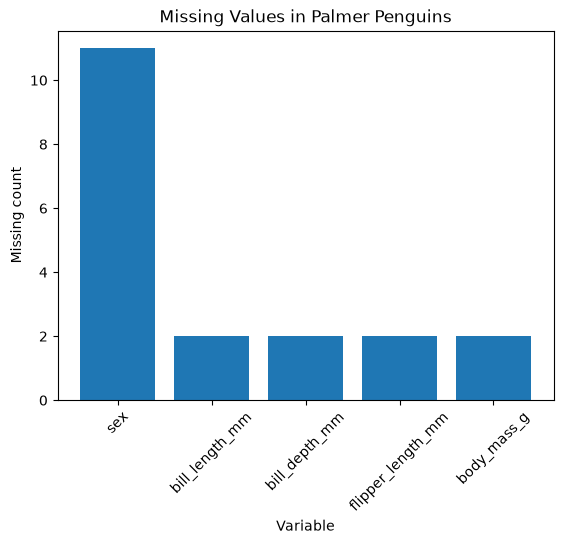

In [5]:
ax = show_missing_values(df)
ax.set_title("Missing Values in Palmer Penguins")
plt.show()

## Section 5. Classify Variables for Analysis

For this EDA, classify variables by how we intend to analyze them.

### Continuous numeric variables

- `bill_length_mm`
- `bill_depth_mm`
- `flipper_length_mm`
- `body_mass_g`

### Categorical variables

- `species`
- `island`
- `sex`

### Ordered study variable

- `year`

The variable classification guides the standard inspection we perform next.


## Section 6. Review Numeric Distributions

A numeric distribution should be inspected before using the variable in relationship analysis.

For each important continuous numeric variable, review:

- count
- missing values
- mean
- standard deviation
- quartiles
- minimum and maximum
- histogram

The summary statistics are computed directly from the data.
The histogram makes the distribution visually inspectable.


In [6]:
numeric_summary = df[NUMERIC_COLS].describe().T
LOG.info(f"Numeric summary:\n{numeric_summary}")

2026-08-23 15:07:31 | INFO | EDA-NB | Numeric summary:
                   count         mean         std     min       25%      50%     75%     max
bill_length_mm     342.0    43.921930    5.459584    32.1    39.225    44.45    48.5    59.6
bill_depth_mm      342.0    17.151170    1.974793    13.1    15.600    17.30    18.7    21.5
flipper_length_mm  342.0   200.915205   14.061714   172.0   190.000   197.00   213.0   231.0
body_mass_g        342.0  4201.754386  801.954536  2700.0  3550.000  4050.00  4750.0  6300.0


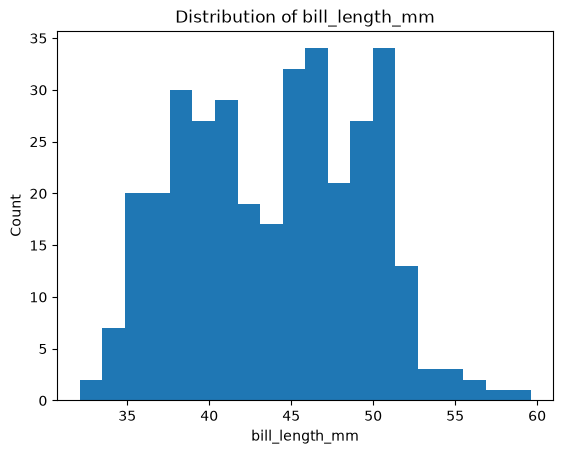

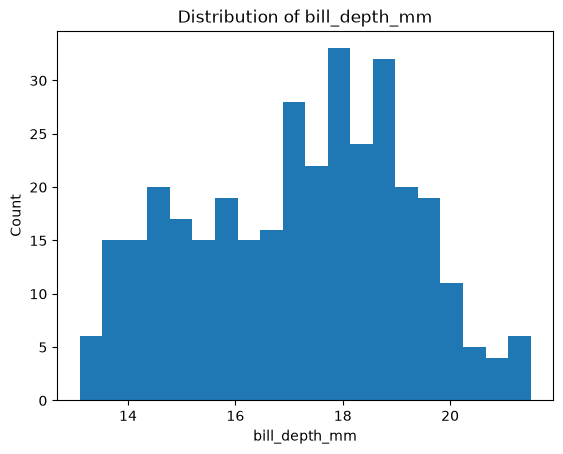

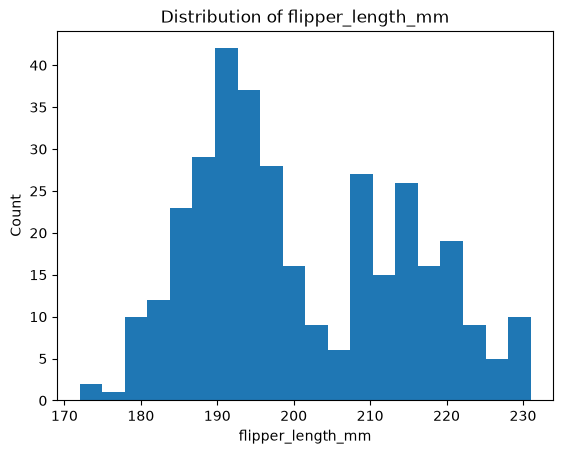

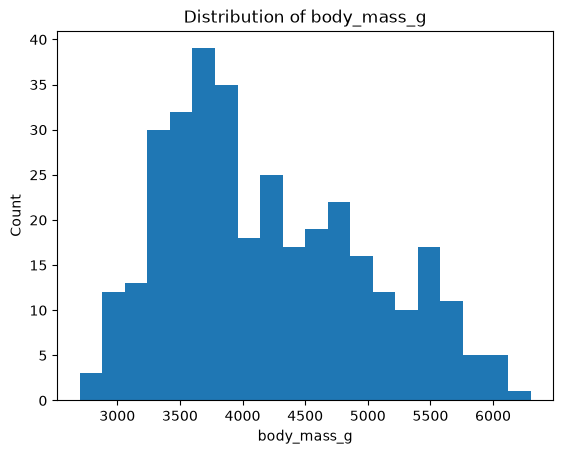

In [7]:
for column in NUMERIC_COLS:
    ax = show_numeric_distribution(
        df,
        column=column,
    )
    ax.set_title(f"Distribution of {column}")
    plt.show()

## Section 7. Review Categorical Distributions

For each important categorical variable, inspect category frequencies to show:

- dominant categories
- rare categories
- missing values
- unexpected category labels


,count
species,
Adelie,152
Gentoo,124
Chinstrap,68


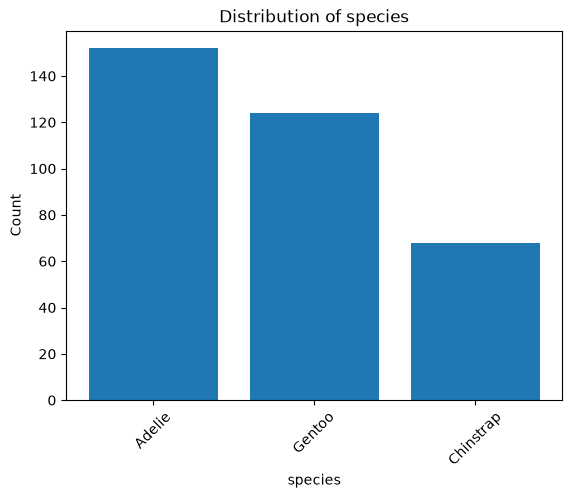

,count
island,
Biscoe,168
Dream,124
Torgersen,52


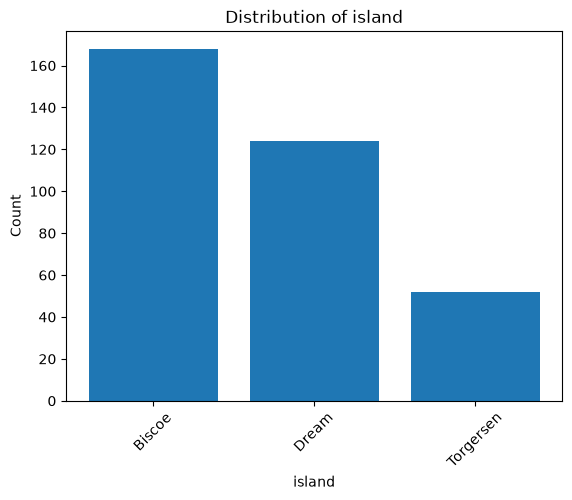

,count
sex,
Male,168
Female,165
NaN,11


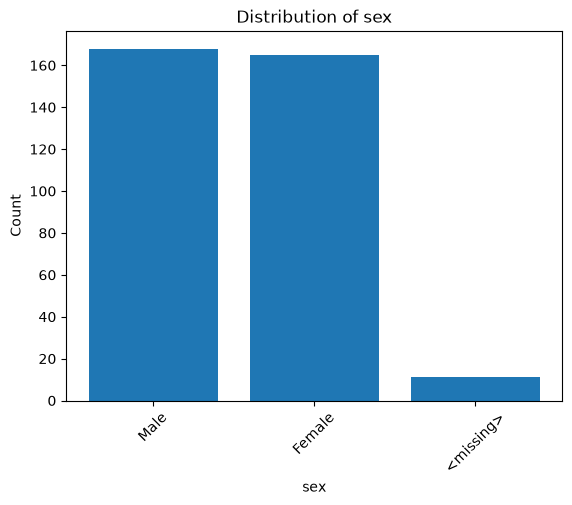

In [8]:
for column in CATEGORICAL_COLS:
    counts = df[column].value_counts(dropna=False)
    display(counts.to_frame(name="count"))

    ax = show_categorical_distribution(
        df,
        column=column,
    )
    ax.set_title(f"Distribution of {column}")
    plt.show()

## Section 8. Investigate a Numeric Relationship

After inspecting variables individually, choose a relationship worth investigating.

Question:

> Do penguins with longer flippers also tend to have greater body mass?

Both variables are continuous numeric, so a scatter plot is appropriate evidence.


2026-08-23 15:07:31 | INFO | EDA-NB | Correlation between flipper_length_mm and body_mass_g: 0.871


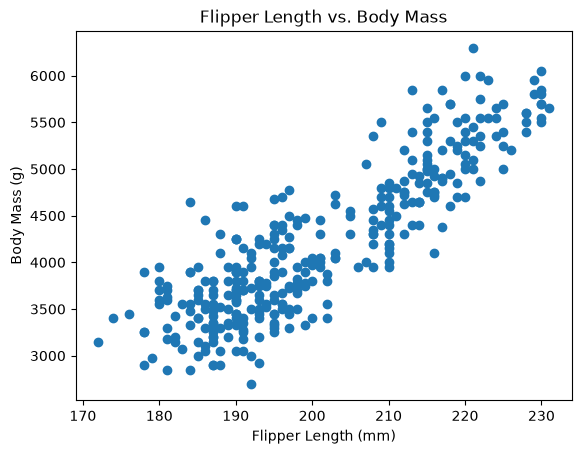

In [9]:
relationship_df = df[["flipper_length_mm", "body_mass_g"]].dropna()

correlation = relationship_df["flipper_length_mm"].corr(relationship_df["body_mass_g"])

LOG.info(f"Correlation between flipper_length_mm and body_mass_g: {correlation:.3f}")

ax = show_numeric_relationship(
    df,
    x="flipper_length_mm",
    y="body_mass_g",
)

ax.set_title("Flipper Length vs. Body Mass")
ax.set_xlabel("Flipper Length (mm)")
ax.set_ylabel("Body Mass (g)")

plt.show()

### Finding

Flipper length and body mass show a strong positive relationship in this dataset.

The correlation and scatter plot provide evidence for that finding.

A finding is a human conclusion supported by analytical evidence.


## Section 9. Compare a Numeric Variable Across Categories

Question:

> How does flipper length differ across penguin species?

This combines:

- one categorical variable: `species`
- one continuous numeric variable: `flipper_length_mm`

A grouped distribution view helps compare the species.


,count,mean,std,min,25%,50%,75%,max
species,,,,,,,,
Adelie,151.0,189.953642,6.539457,172.0,186.0,190.0,195.0,210.0
Chinstrap,68.0,195.823529,7.131894,178.0,191.0,196.0,201.0,212.0
Gentoo,123.0,217.186992,6.484976,203.0,212.0,216.0,221.0,231.0


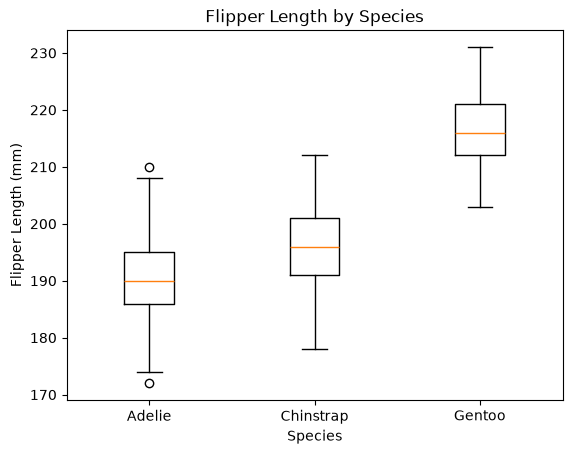

In [10]:
group_summary = df.groupby("species", observed=True)["flipper_length_mm"].describe()

display(group_summary)

ax = show_numeric_by_category(
    df,
    numeric="flipper_length_mm",
    category="species",
)

ax.set_title("Flipper Length by Species")
ax.set_xlabel("Species")
ax.set_ylabel("Flipper Length (mm)")

plt.show()

### Finding

Flipper-length distributions differ across penguin species.

This suggests that species is relevant when interpreting penguin measurements.


## Section 10. Summary and Next Questions

Instructional notes: A repeatable EDA process offers:

- a clear understanding of the dataset grain
- an inventory of variables
- basic data-quality evidence
- standard distribution evidence
- selected relationship evidence
- findings supported by that evidence
- new questions worth investigating

At the end, of your notebook, provide:

-  brief summary of your findings 
-  suggested next steps

WHY: EDA is not a final report.
The summary of your data exploration captures you found 
and what you would like to investigate next.

Your summary will typically be provided in Markdown 
as it is good for narrative. 

### Analyst-Provided Custom Findings

- The dataset contains missing values in several variables.
- The continuous measurements have different ranges and distributions.
- Flipper length and body mass have a strong positive relationship.
- Flipper-length distributions differ across species.

### Analyst-Provided Custom Suggested Next Steps

- Why do the species differ in flipper length?
- Does the relationship between flipper length and body mass differ by species?
- Which missing values matter for a specific future analysis?

## Reminder: Run All before sending to GitHub

Before saving the notebook and pushing to GitHub, use **Run All**
so outputs are generated in the correct order.
